In [1]:
# Plotting global mortality with varying displays of uncertainty

In [50]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import autosize_figure, get_scenario_config

In [11]:
def load_global_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [18]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "UKESM1"
scenario1 = "SSP245_G6"
scenario2 = "G6-1.5K"

n_samples = 300

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1 = load_global_mortality_ensemble_members(model, scenario1, config1, n_samples)
da2 = load_global_mortality_ensemble_members(model, scenario2, config2, n_samples)

da1 = da1.mean("ensemble")
da2 = da2.mean("ensemble")

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


In [ ]:
def plotting_data(da, q1, q2):
    mean = da.mean("samples")
    p1 = da.quantile(q1, "samples")
    p2 = da.quantile(q2, "samples")
    return mean, p1, p2

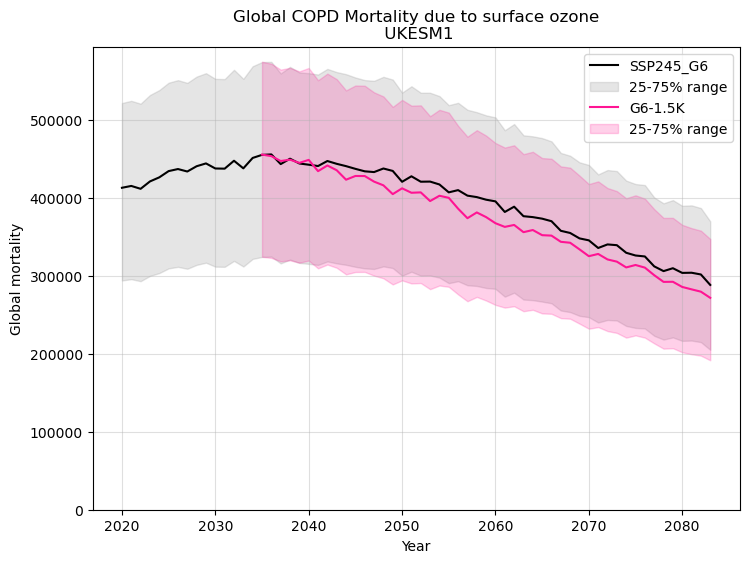

In [51]:
# Quantiles for plotting uncertainty
q1 = 0.25
q2 = 0.75
label = "25-75% range"

da1_mean, da1_p1, da1_p2 = plotting_data(da1, q1, q2)
da2_mean, da2_p1, da2_p2 = plotting_data(da2, q1, q2)

plt.figure(figsize=autosize_figure(1, 1))
plt.plot(da1["year"], da1_mean, color="k", label=scenario1)
plt.fill_between(da1["year"], da1_p1, da1_p2, color="gray", alpha=0.2, label=label)

plt.plot(da2["year"], da2_mean, color="deeppink", label=scenario2)
plt.fill_between(da2["year"], da2_p1, da2_p2, color="deeppink", alpha=0.2, label=label)

plt.ylim(bottom=0)
plt.grid(True, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("Global mortality")
plt.legend()
plt.title(f"Global COPD Mortality due to surface ozone\n {model}")
plt.show()

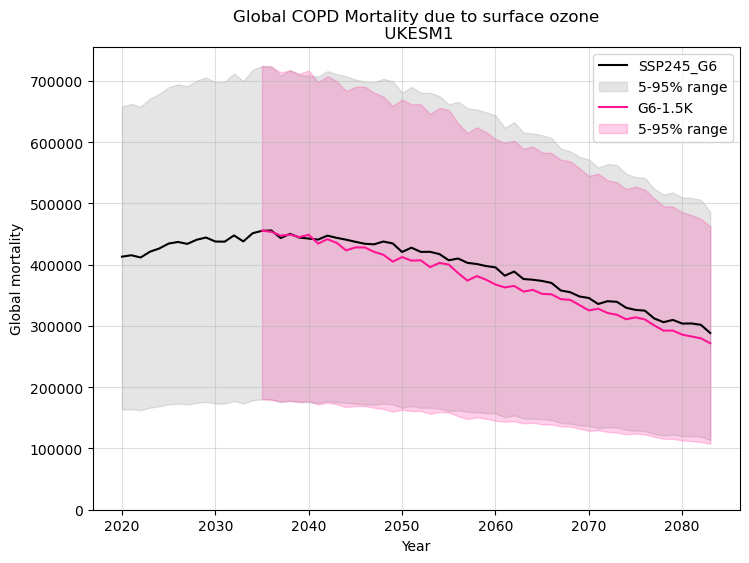

In [52]:
# Quantiles for plotting uncertainty
q1 = 0.05
q2 = 0.95
label = "5-95% range"

da1_mean, da1_p1, da1_p2 = plotting_data(da1, q1, q2)
da2_mean, da2_p1, da2_p2 = plotting_data(da2, q1, q2)

plt.figure(figsize=autosize_figure(1, 1))
plt.plot(da1["year"], da1_mean, color="k", label=scenario1)
plt.fill_between(da1["year"], da1_p1, da1_p2, color="gray", alpha=0.2, label=label)

plt.plot(da2["year"], da2_mean, color="deeppink", label=scenario2)
plt.fill_between(da2["year"], da2_p1, da2_p2, color="deeppink", alpha=0.2, label=label)

plt.ylim(bottom=0)
plt.grid(True, alpha=0.4)
plt.xlabel('Year')
plt.ylabel('Global mortality')
plt.legend()
plt.title(f"Global COPD Mortality due to surface ozone\n {model}")
plt.show()

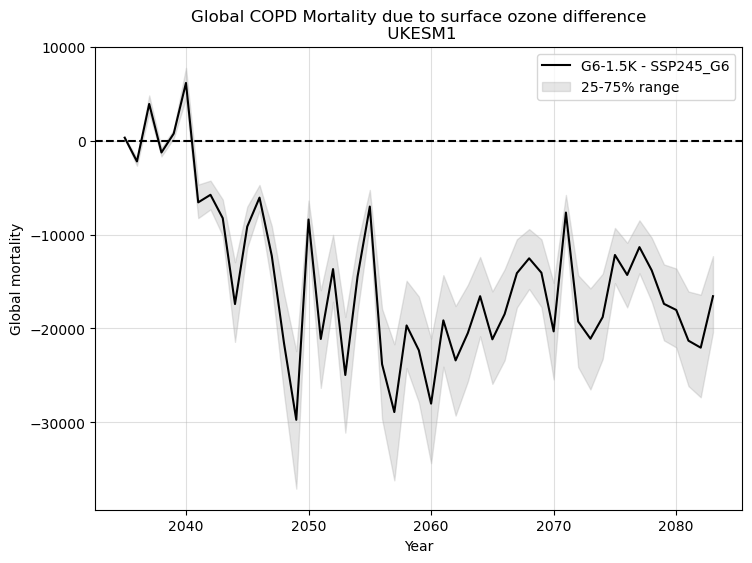

In [53]:
# Quantiles for plotting uncertainty
q1 = 0.25
q2 = 0.75
label = "25-75% range"

difference = da2 - da1  # SAI - noSAI

mean, p1, p2 = plotting_data(difference, q1, q2)

plt.figure(figsize=autosize_figure(1, 1))
plt.plot(difference["year"], mean, color="k", label=f"{scenario2} - {scenario1}")
plt.fill_between(difference["year"], p1, p2, color="gray", alpha=0.2, label=label)

plt.axhline(0, color="k", ls="--", lw=1.5)

plt.grid(True, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("Global mortality")
plt.legend()
plt.title(f"Global COPD Mortality due to surface ozone difference\n {model}")
plt.show()

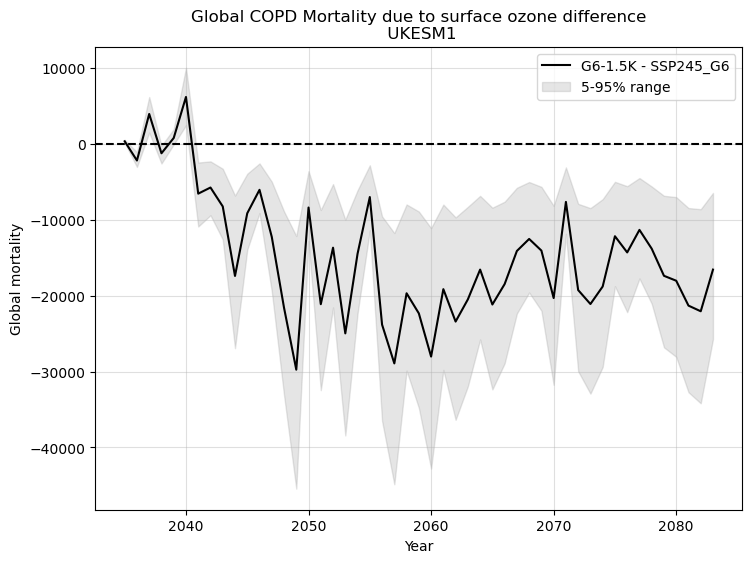

In [54]:
# Quantiles for plotting uncertainty
q1 = 0.05
q2 = 0.95
label = "5-95% range"

difference = da2 - da1  # SAI - noSAI

mean, p1, p2 = plotting_data(difference, q1, q2)

plt.figure(figsize=autosize_figure(1, 1))
plt.plot(difference["year"], mean, color="k", label=f"{scenario2} - {scenario1}")
plt.fill_between(difference["year"], p1, p2, color="gray", alpha=0.2, label=label)

plt.axhline(0, color="k", ls="--", lw=1.5)

plt.grid(True, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("Global mortality")
plt.legend()
plt.title(f"Global COPD Mortality due to surface ozone difference\n {model}")
plt.show()